Using the typing dataset (lightgbm) from that was label encoded duing preprocessing

In [39]:
#Importing dependencies and modules

import pandas as pd
import sklearn 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [40]:
df = pd.read_csv("/users/imbahndu/Desktop/Columbia DBM/Typing dataset/lightbgm.csv")

In [41]:
df

,Unnamed: 0,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,0,85.9,2,128.9,58.6,False,True
1,1,0,132.8,2,500.0,359.4,True,False
2,3,1,171.9,1,390.6,324.2,True,False
3,4,0,99.6,2,261.7,162.1,True,True
4,6,1,105.5,3,453.1,375.0,False,True
...,...,...,...,...,...,...,...,...
247821,337317,0,50.8,0,238.3,160.2,True,True
247822,337319,1,215.8,3,202.1,21.5,False,False
247823,337321,0,132.8,0,367.2,234.4,False,True
247824,337322,1,93.8,1,664.1,570.3,False,True


In [42]:
#Dropping the unmaned column right away
df = df.drop(columns= "Unnamed: 0")

In [43]:
for col in df.columns:
    print(df[col].unique())

[0 1]
[ 85.9 132.8 171.9 ... 162.6  19.8 260.3]
[2 1 3 0]
[128.9 500.  390.6 ... 631.3 255.4 117. ]
[ 58.6 359.4 324.2 ... 493.7 620.  101.8]
[False  True]
[ True False]


In [44]:
df["Parkinsons"].value_counts()

Parkinsons
False    124965
True     122861
Name: count, dtype: int64

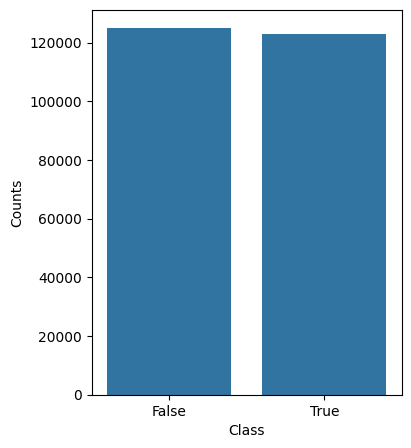

In [45]:
#Visualizations 

class_counts = np.bincount(df["Parkinsons"])

plt.figure(figsize=(4,5))
sns.barplot(x = np.unique(df["Parkinsons"]), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [46]:
#Importing modules
from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [47]:
#Defining the features and labels for dataset 
y = df["Parkinsons"]

X = df.drop(columns=["Parkinsons", "Gender_Male", "Hand", "Direction"])

In [48]:
#Oversampling the minority class in PD
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)



In [49]:
print(X_train.columns.tolist())

['HoldTime', 'LatencyTime', 'FlightTime']


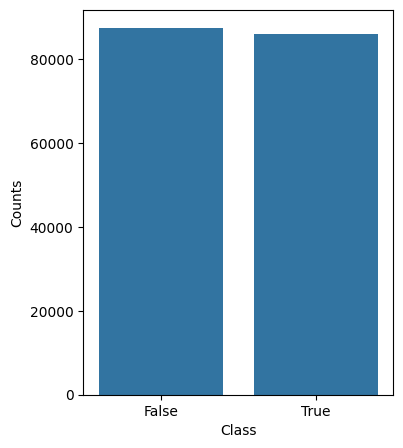

In [50]:
#Visualizations of the PD class after SMOTE
import numpy as np
class_counts = np.bincount(y_train)

plt.figure(figsize=(4, 5))
sns.barplot(x = np.unique(y_train), y=class_counts)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.show()

In [51]:
#Balancing weights

from sklearn.utils import compute_class_weight
import numpy as np

weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))



In [52]:
#Defining hyperparameters in dict-like form

model_lgbm = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    class_weight = class_weight_dict,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.1)

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [54]:
#Fitting the model, training and performing evaluation

model_lgbm.fit(X_train, y_train)

model_lgbm.predict_proba(X_test)

pred = model_lgbm.predict(X_test)

score = model_lgbm.score(X_train, y_train)

acc_score = accuracy_score(y_test, pred)


In [55]:
acc_score

0.5856243611126056

In [56]:
print("Accuracy on the train set", score)

print("Accuracy on the test set", model_lgbm.score(X_test, y_test))

Accuracy on the train set 0.5954991411014653
Accuracy on the test set 0.5856243611126056


In [57]:
#Confusion matrix and classification matrix
cm = confusion_matrix(y_test, pred)
print(cm)

class_report = classification_report(y_test, pred)
print(class_report)

[[23740 13814]
 [16994 19800]]
              precision    recall  f1-score   support

       False       0.58      0.63      0.61     37554
        True       0.59      0.54      0.56     36794

    accuracy                           0.59     74348
   macro avg       0.59      0.59      0.58     74348
weighted avg       0.59      0.59      0.58     74348



<Axes: title={'center': 'Plot of feature importance'}, xlabel='Feature importance', ylabel='Features'>

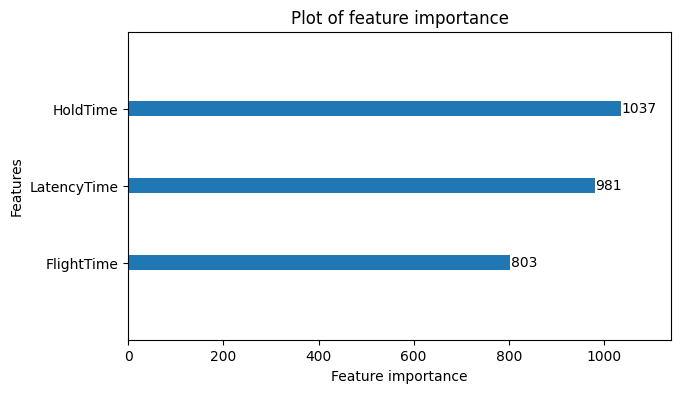

In [58]:
#Plotting important features
lgb.plot_importance(model_lgbm, title="Plot of feature importance", figsize=(7,4), grid=False )

In [59]:
model_lgbm.feature_importances_

array([1037,  981,  803], dtype=int32)

Text(0.5, 1.0, 'ROC plot')

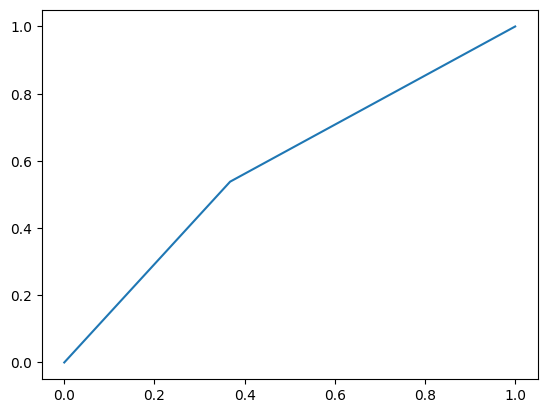

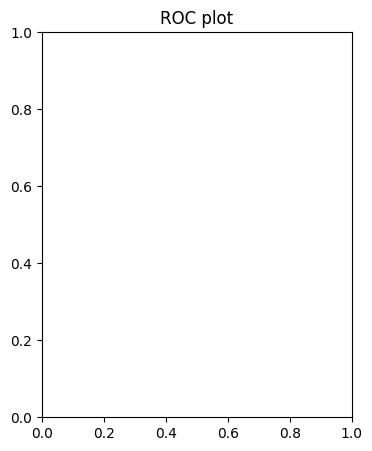

In [60]:
#Plotting roc-curve

from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(y_test, pred)

sns.lineplot(x=fpr, y=tpr)

plt.figure(figsize=(4,5))

plt.title("ROC plot")

Retraining the model with only the most impactful features, so dropping hand and direction

In [61]:
df_new = df.drop(columns = ["Hand", "Gender_Male", "Direction"])

In [62]:
df_new

,HoldTime,LatencyTime,FlightTime,Parkinsons
0,85.9,128.9,58.6,False
1,132.8,500.0,359.4,True
2,171.9,390.6,324.2,True
3,99.6,261.7,162.1,True
4,105.5,453.1,375.0,False
...,...,...,...,...
247821,50.8,238.3,160.2,True
247822,215.8,202.1,21.5,False
247823,132.8,367.2,234.4,False
247824,93.8,664.1,570.3,False


In [63]:
#Defining labels and features, and input vectors
y_final = df_new["Parkinsons"]

X_final = df_new.drop(columns=["Parkinsons"])

X_train_new, X_test_final, y_train_new, y_test_final = train_test_split(X_final, y_final, random_state=42, test_size=0.3)

smote_final = SMOTE(random_state = 42)

X_train_final, y_train_final = smote_final.fit_resample(X_train_new, y_train_new)

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [64]:
print("Train columns:", X_train_final.columns.tolist())
print("Test columns:", X_test_final.columns.tolist())

Train columns: ['HoldTime', 'LatencyTime', 'FlightTime']
Test columns: ['HoldTime', 'LatencyTime', 'FlightTime']


In [65]:
model_final = lgb.LGBMClassifier(objective= "binary",
    num_leaves = 30,
    force_col_wise = True,
    max_depth = 6,
    n_estimators= 100,
    learning_rate = 0.5, verbose=-1)

In [66]:
#Fitting the model, evaluating the model, 
model_final.fit(X_train_final, y_train_final)

final_pred = model_final.predict(X_test_final)

score_final = model_final.score(X_train_final, y_train_final)


In [67]:
#Printing the evalutaion metrics
print(accuracy_score(y_test, final_pred))
print()

print(confusion_matrix(y_test, final_pred))
print()

print(classfication_report(y_test, final_pred))
print()

0.5946763867219024

[[23896 13658]
 [16477 20317]]



NameError: name 'classfication_report' is not defined

Hyperparameter tuning with RandomizedSearchCV since the dataset is large 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, KFold

In [ ]:
#Cross validation 
kfold = KFold(n_splits=5, random_state = 42, shuffle=True)

param_grid = {
    "num_leaves": np.arange(20,80,10).tolist(),
    "max_depth": np.arange(4, 12, 4).tolist(),
    "learning_rate": [0.01, 0.05, 0.1],
    "feature_fraction": [0.7, 0.8,0.9],
    "bagging_fraction":[0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 50],
    "min_split_gain": [0.0, 0.01, 0.1],

}

grid = RandomizedSearchCV(estimator=model_final, param_distributions=param_grid, cv=kfold)

In [ ]:
grid.fit(X_train_final, y_train_final)

RandomizedSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=LGBMClassifier(force_col_wise=True,
                                            learning_rate=0.5, max_depth=6,
                                            num_leaves=30, objective='binary',
                                            verbose=-1),
                   param_distributions={'bagging_fraction': [0.7, 0.8, 0.9],
                                        'feature_fraction': [0.7, 0.8, 0.9],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 8],
                                        'min_child_samples': [10, 20, 50],
                                        'min_split_gain': [0.0, 0.01, 0.1],
                                        'num_leaves': [20, 30, 40, 50, 60, 70]})

In [ ]:
#Pulling the best hyperparamters

grid_best = grid.best_params_
grid.best_score_

0.577491380198172

In [ ]:
#Training new model based on hyperparamters from RSCV

model =  lgb.LGBMClassifier(objective= "binary",
    num_leaves = grid_best["num_leaves"],
    min_split_gain = grid_best["min_split_gain"],
    min_child_samples = grid_best["min_child_samples"],
    force_col_wise = True,
    max_depth = grid_best["max_depth"],
    learning_rate = grid_best["learning_rate"],
    feature_fraction = grid_best["feature_fraction"],
    bagging_fraction = grid_best["bagging_fraction"],
    n_estimators= 100)

In [ ]:
#Fitting and making predictions on test data
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(accuracy_score(y_test, predictions))


0.5740003103822875


In [ ]:
#Confusion matrix and classification report

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

[[6256 3487]
 [4748 4840]]
              precision    recall  f1-score   support

       False       0.57      0.64      0.60      9743
        True       0.58      0.50      0.54      9588

    accuracy                           0.57     19331
   macro avg       0.57      0.57      0.57     19331
weighted avg       0.57      0.57      0.57     19331



Text(0.5, 1.0, 'ROC plot')

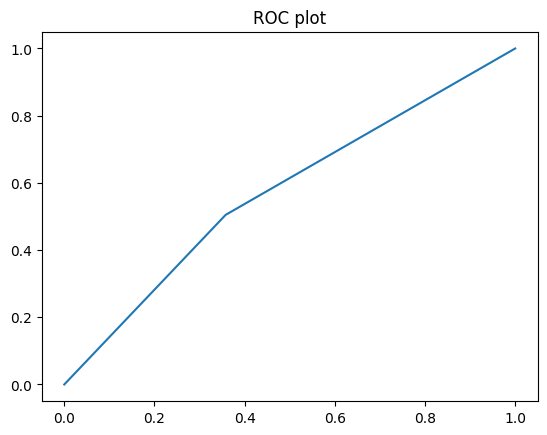

In [ ]:
#Visualizations and plotting  roc
fpr, tpr, threshold = roc_curve(y_test, predictions)

sns.lineplot(x=fpr, y=tpr,)

plt.title("ROC plot")